# Personal Expense Tracker (31 Days)

This project analyzes **real-world daily expenses** using Python and Pandas.
The dataset is based on a student's day-to-day spending pattern where:
- Minimum daily expense is ₹100
- Travel (bus) expense occurs on weekdays
- Weekends have lifestyle-related expenses


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


## Dataset Description

The dataset (`expenses.csv`) contains daily expenses with the following columns:

- **Date** – Date of the expense  
- **Category** – Type of expense (Food, Travel, Study, Other)  
- **Amount** – Expense amount in INR  
- **Note** – Short description of the expense

In [3]:
df = pd.read_csv("D:/Mini project/expenses.csv")
df.head()

,Date,Category,Amount,Note
0,01/01/2026,Food,30,Tea
1,01/01/2026,Travel,40,Bus
2,01/01/2026,Food,50,Lunch
3,02/01/2026,Food,30,Tea
4,02/01/2026,Travel,40,Bus


## Data Preprocessing

- Convert the Date column into datetime format  
- Ensure data is clean and ready for analysis


In [4]:
df["Date"] = pd.to_datetime(df["Date"], format="%d/%m/%Y")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84 entries, 0 to 83
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Date      84 non-null     datetime64[ns]
 1   Category  84 non-null     object        
 2   Amount    84 non-null     int64         
 3   Note      84 non-null     object        
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 2.8+ KB


## Complete Expense Data

The following table shows all expenses recorded for 31 days.


In [5]:
df


,Date,Category,Amount,Note
0,2026-01-01,Food,30,Tea
1,2026-01-01,Travel,40,Bus
2,2026-01-01,Food,50,Lunch
3,2026-01-02,Food,30,Tea
4,2026-01-02,Travel,40,Bus
...,...,...,...,...
79,2026-01-30,Food,30,Tea
80,2026-01-30,Travel,40,Bus
81,2026-01-30,Food,70,Lunch
82,2026-01-31,Food,30,Snacks


## Total Monthly Expense

This section calculates the total expense for the entire 31-day period.


In [6]:
total_expense = df["Amount"].sum()
total_expense

np.int64(4570)

## Key Expense KPIs

A quick summary of the key spending metrics and overall expenses.


In [7]:
total_expense = df['Amount'].sum()
average_daily_expense = df['Amount'].mean()
highest_expense = df['Amount'].max()
lowest_expense = df['Amount'].min()
transaction_count = len(df)

print(f'Total Expense: ₹{total_expense:,.2f}')
print(f'Average Expense: ₹{average_daily_expense:,.2f}')
print(f'Highest Expense: ₹{highest_expense:,.2f}')
print(f'Lowest Expense: ₹{lowest_expense:,.2f}')
print(f'Number of Transactions: {transaction_count}')

Total Expense: ₹4,570.00
Average Expense: ₹54.40
Highest Expense: ₹370.00
Lowest Expense: ₹10.00
Number of Transactions: 84


## Daily Expense Analysis

Expenses are grouped by date to calculate the total spending per day.
This helps in checking if the minimum daily expense condition is met.


In [8]:
daily_expense = df.groupby("Date")["Amount"].sum()
daily_expense


Date
2026-01-01    120
2026-01-02    130
2026-01-03    120
2026-01-04    420
2026-01-05    160
2026-01-06     80
2026-01-07    140
2026-01-08    130
2026-01-09    150
2026-01-10     90
2026-01-11    260
2026-01-12    140
2026-01-13    130
2026-01-14    150
2026-01-15    120
2026-01-16    140
2026-01-17    110
2026-01-18    110
2026-01-19    130
2026-01-20    120
2026-01-21    150
2026-01-22    130
2026-01-23    140
2026-01-24    200
2026-01-25    110
2026-01-26    120
2026-01-27    140
2026-01-28    130
2026-01-29    270
2026-01-30    140
2026-01-31     90
Name: Amount, dtype: int64

## Minimum Daily Expense Validation

Each day's total expense should be **at least ₹100**.
Days with expenses below ₹100 are identified below.

In [9]:
low_expense_days = daily_expense[daily_expense < 100]
low_expense_days if not low_expense_days.empty else "All days meet the minimum ₹100 expense requirement"

Date
2026-01-06    80
2026-01-10    90
2026-01-31    90
Name: Amount, dtype: int64

## Category-wise Expense Analysis

Expenses are grouped by category to identify spending patterns.


In [10]:
category_total = df.groupby("Category")["Amount"].sum()
category_total

Category
Food      2220
Other     1100
Study      370
Travel     880
Name: Amount, dtype: int64

## Highest Spending Category

This section identifies the category with the highest total expense.


In [11]:
category_total.idxmax(), category_total.max()


('Food', np.int64(2220))

## Average Daily Expense

The average daily expense is calculated for the 31-day period.


In [12]:
average_daily_expense = total_expense / daily_expense.count()
round(average_daily_expense, 2)

np.float64(147.42)

## Weekday vs Weekend Analysis

In [17]:
df['Day_Type'] = np.where(df['Date'].dt.dayofweek >= 5, 'Weekend', 'Weekday')
day_type_summary = df.groupby('Day_Type')['Amount'].agg(['sum', 'mean', 'count'])
day_type_summary

,sum,mean,count
Day_Type,,,
Weekday,3060,46.363636,66
Weekend,1510,83.888889,18


Compare total spending between weekdays and weekends.

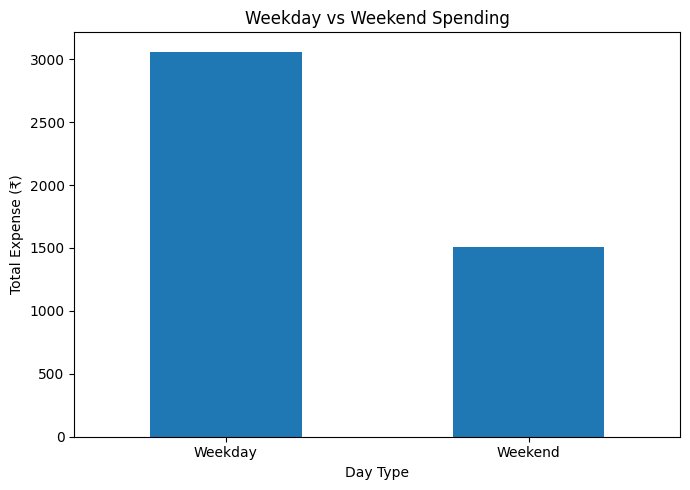

In [18]:
day_type_summary['sum'].plot(kind='bar', figsize=(7, 5))
plt.title('Weekday vs Weekend Spending')
plt.xlabel('Day Type')
plt.ylabel('Total Expense (₹)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Budget Analysis

Analyze the monthly budget by comparing the planned budget with actual spending, budget usage, and the remaining amount

In [19]:

monthly_budget = 5000

budget_used = total_expense / monthly_budget * 100
remaining_budget = monthly_budget - total_expense

print(f'Monthly Budget: ₹{monthly_budget:,.2f}')
print(f'Actual Spending: ₹{total_expense:,.2f}')
print(f'Budget Used: {budget_used:.2f}%')
print(f'Remaining Budget: ₹{remaining_budget:,.2f}')

Monthly Budget: ₹5,000.00
Actual Spending: ₹4,570.00
Budget Used: 91.40%
Remaining Budget: ₹430.00


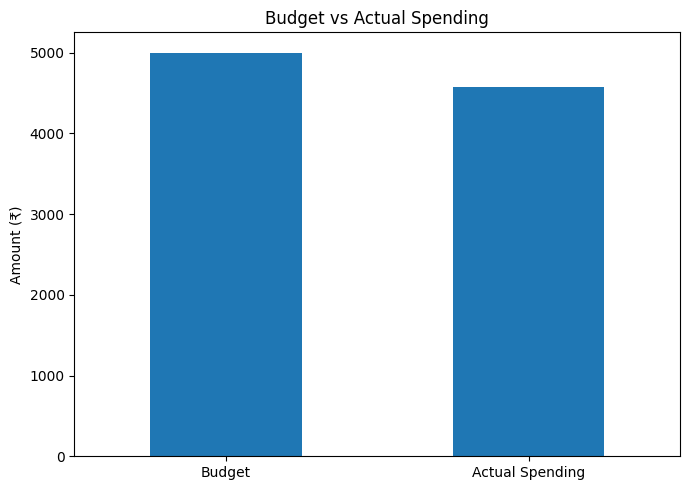

In [20]:
budget_data = pd.Series({'Budget': monthly_budget, 'Actual Spending': total_expense})
budget_data.plot(kind='bar', figsize=(7, 5))
plt.title('Budget vs Actual Spending')
plt.ylabel('Amount (₹)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Expense Visualization

Visual representations help understand spending patterns clearly.


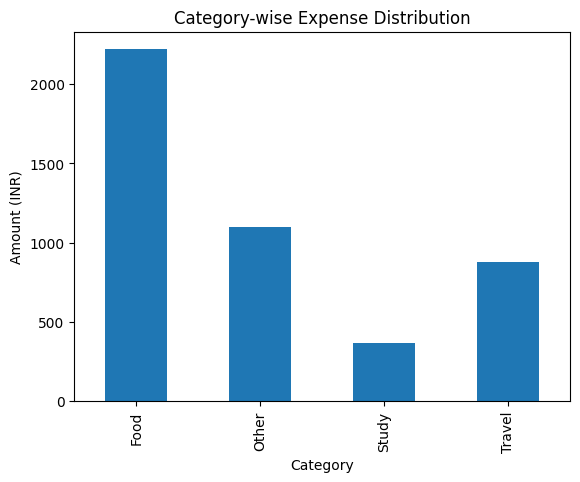

In [13]:
category_total.plot(kind="bar", title="Category-wise Expense Distribution")
plt.xlabel("Category")
plt.ylabel("Amount (INR)")
plt.show()

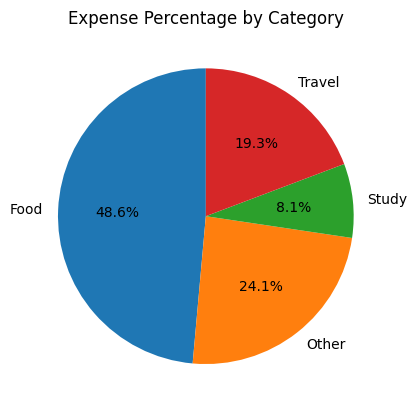

In [14]:
category_total.plot(kind="pie", autopct="%1.1f%%", startangle=90)
plt.ylabel("")
plt.title("Expense Percentage by Category")
plt.show()

## Conclusion

This mini-project demonstrates how Python and Pandas can be used to analyze
real-world financial data. It helped in understanding:
- Data handling
- Grouping and aggregation
- Basic data visualization
